In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۶ — تکنیک‌های یادگیری تجمعی (Ensemble Learning)
## درس ۱: یادگیری تجمعی چیست؟

> **یادداشت مخزن**: این درس طبق درخواست شما با نام **`Chapter6_Lesson8_Fa.ipynb`** ذخیره شده است.  
> محتوای آن مربوط به **فصل ۶، درس ۱** («یادگیری تجمعی چیست؟») است.

### در این درس چه یاد می‌گیرید
- «انسمبل» چیست و چرا ترکیب چند مدل معمولاً از یک مدل بهتر عمل می‌کند.
- سه سازوکار اصلی: **کاهش واریانس (Bagging)**، **کاهش بایاس (Boosting)** و **کاهش ریسک از طریق تجمیع**.
- نقش **تنوع (Diversity)** (عدم هم‌بستگی خطاها) و روش‌های ایجاد آن.
- یک گردش‌کار عملی و قابل‌استفادهٔ مجدد در scikit-learn: **Pipeline + پیش‌پردازش + انسمبل‌ها**.
- آزمایش‌های عملی روی **چند دیتاست** از مخزن شما (به‌صورت برنامه‌وار انتخاب می‌شوند).

---



## ۰) آماده‌سازی: نمادگذاری و یک مدل ذهنی تمیز

یک مسئلهٔ یادگیری نظارت‌شده را می‌توان این‌گونه نوشت:

- داده: $(x_i, y_i)_{i=1}^n$ که به‌صورت i.i.d. از یک توزیع ناشناخته $\mathcal{D}$ نمونه‌برداری شده‌اند.
- یک فرضیه/مدل: $f_\theta: \mathcal{X} \to \mathcal{Y}$.
- تابع هزینه $\ell(\hat{y}, y)$.

**ریسک جمعیتی** (خطای واقعی/تعمیم) برابر است با:

$$
R(f) = \mathbb{E}_{(X,Y)\sim\mathcal{D}}\big[\ell(f(X), Y)\big],
$$

و **ریسک تجربی** (هدف روی دادهٔ آموزشی):

$$
\hat{R}_n(f) = \frac{1}{n}\sum_{i=1}^n \ell(f(x_i), y_i).
$$

### انسمبل چیست؟

«انسمبل» یک پیش‌بین است که با ترکیب چند پیش‌بین پایه ساخته می‌شود:

$$
f_{\text{ens}}(x) = \mathcal{A}\big(f_1(x), f_2(x), \dots, f_M(x)\big),
$$

که در آن $\mathcal{A}$ یک **قاعدهٔ تجمیع** است؛ مثل:

- **میانگین‌گیری** (برای رگرسیون یا طبقه‌بندی احتمالاتی)،
- **رأی‌گیری اکثریت** (Hard Voting)،
- **رأی‌گیری وزن‌دار** (Soft Voting / میانگین وزن‌دار)،
- **متا-یادگیری** (Stacking): یادگیری $\mathcal{A}$ از داده.

تمام حوزهٔ یادگیری تجمعی را می‌توان مطالعهٔ یک سؤال دانست:

> چه زمانی (و چرا) ترکیب چند مدلِ ناقص، پیش‌بینی می‌سازد که ریسک آن $R(f_{\text{ens}})$ از ریسک هر مدل منفرد $R(f_m)$ کمتر باشد؟

---



## ۱) چرا انسمبل‌ها کار می‌کنند: سه اهرم اصلی

بهبود عملکرد انسمبل‌ها عمدتاً از طریق اثرگذاری بر **(۱) واریانس**، **(۲) بایاس** و **(۳) کالیبراسیون/ریسکِ قواعد امتیازدهی درست** رخ می‌دهد.

### ۱.۱ کاهش واریانس با میانگین‌گیری (شهود Bagging)

برای رگرسیون با هزینهٔ مربعی، فرض کنید سیگنال واقعی چنین است:

$$
Y = f^\star(X) + \varepsilon,\qquad \mathbb{E}[\varepsilon\mid X]=0,\quad \mathrm{Var}(\varepsilon\mid X)=\sigma_\varepsilon^2.
$$

$\hat{f}(x)$ را یک برآوردگر یادگرفته‌شده از یک نمونهٔ آموزشی تصادفی در نظر بگیرید. تجزیهٔ کلاسیک **بایاس–واریانس** (به‌صورت نقطه‌ای در $x$) می‌گوید:

$$
\mathbb{E}\big[(Y-\hat{f}(x))^2\mid X=x\big]
=
\sigma_\varepsilon^2
+
\big(\mathrm{Bias}[\hat{f}(x)]\big)^2
+
\mathrm{Var}[\hat{f}(x)].
$$

اکنون یک انسمبل با میانگین‌گیری از $M$ برآوردگر بسازید:

$$
\bar{f}(x) = \frac{1}{M}\sum_{m=1}^M \hat{f}_m(x).
$$

اگر یادگیرنده‌های پایه بایاس مشابهی داشته باشند، میانگین‌گیری عمدتاً **واریانس** را کاهش می‌دهد. همانیِ کلیدی:

$$
\mathrm{Var}\!\left[\bar{f}(x)\right]
=
\frac{1}{M^2}\sum_{m=1}^M \mathrm{Var}[\hat{f}_m(x)]
+
\frac{2}{M^2}\sum_{i<j}\mathrm{Cov}\big(\hat{f}_i(x), \hat{f}_j(x)\big).
$$

اگر همهٔ یادگیرنده‌ها واریانس $\sigma^2$ و هم‌بستگی جفتی $\rho$ داشته باشند (تقریب بسیار رایج):

$$
\mathrm{Var}\!\left[\bar{f}(x)\right]
=
\frac{\sigma^2}{M}\big(1 + (M-1)\rho\big).
$$

**تعبیر**:
- اگر $\rho \approx 0$ (خطاها تقریباً نامرتبط باشند)، واریانس تقریباً مثل $\sigma^2/M$ کم می‌شود — بهبود بزرگ.
- اگر $\rho \approx 1$ (یادگیرنده‌ها تقریباً یکسان رفتار کنند)، واریانس تقریباً کم نمی‌شود — بهبود ناچیز.

پس اولین درس کلیدی این است:

> انسمبل به **تنوع (Diversity)** نیاز دارد. تنوع یعنی «اشتباهات یکسان نداشتن».

Bagging با نمونه‌برداری مجدد (Bootstrap) تنوع ایجاد می‌کند.

---

### ۱.۲ کاهش خطا با رأی‌گیری اکثریت (شهود طبقه‌بندی)

فرض کنید $M$ طبقه‌بند دودویی هرکدام به‌طور مستقل با احتمال $p < 1/2$ خطا می‌کنند و ما از **رأی اکثریت** استفاده می‌کنیم.

اگر $K$ تعداد طبقه‌بندهای اشتباه باشد، آنگاه $K \sim \mathrm{Binomial}(M,p)$. انسمبل زمانی اشتباه می‌کند که $K > M/2$:

$$
\mathbb{P}(\text{ensemble wrong})
=
\sum_{k=\lceil M/2\rceil}^{M}
\binom{M}{k}p^k(1-p)^{M-k}.
$$

با بزرگ شدن $M$، اگر $p<1/2$ باشد و استقلال تقریباً برقرار باشد، این احتمال می‌تواند سریعاً به صفر نزدیک شود.
این ایده با **قضیهٔ هیئت منصفهٔ کُندورسه** (wisdom of crowds) مرتبط است.

در عمل، استقلال کامل واقع‌گرایانه نیست و خطاها هم‌بسته‌اند؛ با این حال نتیجهٔ کیفی درست می‌ماند:
اگر هم‌بستگی خطاها کاهش یابد، رأی‌گیری بهتر می‌شود.

---

### ۱.۳ قواعد امتیازدهی درست و نامساوی ینسن (چرا میانگین‌گیری از احتمال‌ها مفید است)

برای طبقه‌بندی احتمالاتی، اغلب **log-loss** (cross-entropy) را کمینه می‌کنیم:

$$
\ell(\hat{p}, y) = -\big( y\log\hat{p} + (1-y)\log(1-\hat{p}) \big).
$$

برای $y \in \{0,1\}$، تابع $\ell(\hat{p}, y)$ روی $(0,1)$ نسبت به $\hat{p}$ **کوژ** (convex) است.
طبق **نامساوی ینسن**، برای هر تابع کوژ $\phi$ داریم:

$$
\phi\!\left(\frac{1}{M}\sum_{m=1}^M z_m\right) \le \frac{1}{M}\sum_{m=1}^M \phi(z_m).
$$

اگر $\phi(\cdot)=\ell(\cdot, y)$ و $z_m=\hat{p}_m$ باشد:

$$
\ell\!\left(\frac{1}{M}\sum_{m}\hat{p}_m,\;y\right)
\le
\frac{1}{M}\sum_m \ell(\hat{p}_m, y).
$$

بنابراین **میانگین‌گیری از احتمال‌ها نمی‌تواند میانگین log-loss را افزایش دهد** (برای همان هدف $y$) و اغلب آن را کاهش می‌دهد.
این یک دلیل عمیق برای قدرت «Soft Voting» و میانگین‌گیری از احتمال‌هاست.

---



## ۲) تنوع (Diversity): مادهٔ اولیهٔ غیرقابل مذاکره

انسمبل فقط «مدل‌های زیاد» نیست؛ بلکه «مدل‌های زیادِ *متفاوت*» است.

### ۲.۱ منابع رایج تنوع

۱) **تنوع داده**
- Bootstrap (در Bagging)
- زیرنمونه‌گیری یا فولدهای مختلف
- پنجره‌های زمانی متفاوت (در سری زمانی)

۲) **تنوع ویژگی**
- Random Subspace: نمونه‌گیری ویژگی‌ها برای هر یادگیرنده (Random Forest / ExtraTrees)
- پایپ‌لاین‌های متفاوت پیش‌پردازش

۳) **تنوع مدل**
- استفاده از مدل‌های ناهمگن (خطی + درختی + SVM + kNN)
- هایپرپارامترهای متفاوت

۴) **تنوع ناشی از تصادفی‌بودن**
- seedهای متفاوت
- بهینه‌سازی تصادفی

### ۲.۲ سنجه‌های تنوع (ابزارهای مفهومی)

اگر $e_i \in \{0,1\}$ نشانگر خطای طبقه‌بند $i$ روی یک نمونه باشد (۱=اشتباه)، آنگاه:

- **نرخ عدم توافق** بین $i$ و $j$:
  $$\mathbb{P}(e_i \ne e_j).$$

- **هم‌بستگی خطاها**:
  $$\rho_{ij} = \mathrm{Corr}(e_i, e_j).$$

- **Q-statistic** (در تحلیل انسمبل‌ها رایج است):
  مبتنی بر جدول ۲×۲ درست/غلط دو طبقه‌بند.

در کار روزمره معمولاً نیازی به محاسبهٔ این‌ها ندارید، اما توضیح می‌دهند چرا گاهی انسمبل «کمکی نمی‌کند»:
یادگیرنده‌ها بیش از حد هم‌بسته‌اند.

---



## ۳) رده‌بندی روش‌های انسمبل (نمای کلی)

### ۳.۱ خانوادهٔ Bagging (کاهش واریانس)
- Bootstrap Aggregating (BaggingClassifier/Regressor)
- Random Forest (bagging + تصادفی‌سازی ویژگی)
- ExtraTrees (تصادفی‌سازی بیشتر در splitها و اغلب افزایش تنوع)

**مدل ذهنی**: تعداد زیادی مدل پایهٔ *پر‌واریانس* (معمولاً درخت‌ها) بسازید و میانگین بگیرید.

---

### ۳.۲ خانوادهٔ Boosting (کاهش بایاس + بهبود margin)
- AdaBoost (وزن‌دهی مجدد به نمونه‌ها؛ تمرکز روی نقاط سخت)
- Gradient Boosting (افزودن یادگیرنده‌ها برای برازش باقیمانده‌ها/گرادیان منفی)
- نسخه‌های مدرن: XGBoost, LightGBM, CatBoost (در فصل‌های بعدی)

**مدل ذهنی**: یک مدل جمعی (additive) بسازید
$$
F_M(x) = \sum_{m=1}^M \alpha_m h_m(x)
$$
که در آن هر یادگیرندهٔ جدید، خطاهای انسمبلِ فعلی را اصلاح می‌کند.

---

### ۳.۳ خانوادهٔ Stacking (تجمیعِ یادگرفته‌شده)
- آموزش مدل‌های پایه روی فولدهای آموزش
- استفاده از پیش‌بینی‌های out-of-fold به‌عنوان ویژگی
- آموزش یک meta-model روی آن‌ها

**مدل ذهنی**: اجازه دهید داده یاد بگیرد چگونه مدل‌ها را ترکیب کند.

---

### ۳.۴ Voting / Averaging (پایه‌های ساده اما قوی)
- Hard vote: $\arg\max_k \sum_m \mathbf{1}[\hat{y}_m=k]$
- Soft vote: میانگین احتمال‌ها و سپس انتخاب argmax

**مدل ذهنی**: با میانگین‌گیری از احتمال‌های کالیبره، ریسک را کاهش دهید.

---



## ۴) نمودار گردش‌کار: از مدل‌های پایه تا انسمبل

```mermaid
flowchart TD
    A["Start: dataset X, y"] --> B["Preprocess: split columns; encode; scale"]
    B --> C["Train diverse base learners"]
    C --> D{"Aggregation rule"}
    D -->|"Averaging / soft vote"| E["Ensemble probabilities"]
    D -->|"Hard vote"| F["Majority decision"]
    D -->|"Stacking"| G["Meta-model on base predictions"]
    E --> H["Evaluate: metrics + calibration"]
    F --> H
    G --> H
    H --> I["Iterate: tune diversity and bias/variance"]
```

---



In [2]:
# Core scientific Python
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Utilities
from pathlib import Path

# Scikit-learn core
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

# Base learners
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Ensemble methods
from sklearn.ensemble import (
    VotingClassifier, VotingRegressor,
    BaggingClassifier, BaggingRegressor,
    RandomForestClassifier, RandomForestRegressor,
    AdaBoostClassifier, GradientBoostingClassifier,
    GradientBoostingRegressor
)

np.random.seed(7)

## ۵) بارگذاری دیتاست‌ها از مخزن شما (همراه با fallback امن)

شما چند دیتاست را زیر مسیرهای زیر معرفی کردید:

- طبقه‌بندی: `../../../Datasets/Classification/...`
- رگرسیون: `../../../Datasets/Regression/...`

در مخزن شما، این مسیرها زمانی درست resolve می‌شوند که نوت‌بوک در این مسیر باشد:

`Tutorials/Persian/Chapter6/Chapter6_Lesson8_Fa.ipynb` (و مشابه آن در انگلیسی).

لودر زیر:
- به‌صورت تصادفی **یک دیتاست طبقه‌بندی** و **یک دیتاست رگرسیون** انتخاب می‌کند،
- اگر فایل‌ها موجود باشند از دیسک می‌خواند،
- و در غیر این صورت یک دیتاست مصنوعی کوچک می‌سازد (تا نوت‌بوک در محیط‌های جدا نیز اجرا شود).

> این درس از **چند دیتاست** استفاده می‌کند تا «همه‌چیز با یک دیتاست» نباشد و رفتار انسمبل‌ها در مسائل مختلف دیده شود.



In [3]:
from typing import Tuple, Optional

CLASSIFICATION_FILES = [
    "../../../Datasets/Classification/diabetes.csv",
    "../../../Datasets/Classification/drug200.csv",
    "../../../Datasets/Classification/fish.csv",
    "../../../Datasets/Classification/glass.csv",
    "../../../Datasets/Classification/iris.csv",
    "../../../Datasets/Classification/stars.csv",
    "../../../Datasets/Classification/Wine_Quality.csv",
]

REGRESSION_FILES = [
    "../../../Datasets/Regression/cognitive.csv",
    "../../../Datasets/Regression/diamonds.csv",
    "../../../Datasets/Regression/earthquake.csv",
    "../../../Datasets/Regression/European_Ski_Resorts.csv",
    "../../../Datasets/Regression/house-prices.csv",
    "../../../Datasets/Regression/listings.csv",
    "../../../Datasets/Regression/NYC_Collisions.csv",
    "../../../Datasets/Regression/salaries.csv",
    "../../../Datasets/Regression/states_all.csv",
]

def _read_csv_if_exists(path: str) -> Optional[pd.DataFrame]:
    p = Path(path)
    if p.exists():
        return pd.read_csv(p)
    return None

def pick_random_dataset(paths, seed=7):
    rng = np.random.default_rng(seed)
    return paths[int(rng.integers(0, len(paths)))]

def load_classification(seed=7) -> Tuple[pd.DataFrame, str]:
    path = pick_random_dataset(CLASSIFICATION_FILES, seed=seed)
    df = _read_csv_if_exists(path)
    if df is None:
        # Fallback: simple synthetic binary classification
        rng = np.random.default_rng(seed)
        X = rng.normal(size=(400, 6))
        w = rng.normal(size=6)
        logits = X @ w
        y = (logits > np.median(logits)).astype(int)
        cols = [f"x{i}" for i in range(X.shape[1])]
        df = pd.DataFrame(X, columns=cols)
        df["classification"] = np.where(y == 1, "Class1", "Class0")
        return df, "SYNTHETIC_CLASSIFICATION"
    return df, path

def load_regression(seed=7) -> Tuple[pd.DataFrame, str]:
    path = pick_random_dataset(REGRESSION_FILES, seed=seed)
    df = _read_csv_if_exists(path)
    if df is None:
        # Fallback: synthetic regression
        rng = np.random.default_rng(seed)
        X = rng.normal(size=(500, 5))
        y = X @ rng.normal(size=5) + rng.normal(scale=0.8, size=500)
        cols = [f"x{i}" for i in range(X.shape[1])]
        df = pd.DataFrame(X, columns=cols)
        df["target"] = y
        return df, "SYNTHETIC_REGRESSION"
    return df, path

cls_df, cls_path = load_classification(seed=7)
reg_df, reg_path = load_regression(seed=11)  # different seed => likely different file

print("Chosen classification dataset:", cls_path)
print("Shape:", cls_df.shape)
display(cls_df.head())

print("\nChosen regression dataset:", reg_path)
print("Shape:", reg_df.shape)
display(reg_df.head())

Chosen classification dataset: ../../../Datasets/Classification/Wine_Quality.csv
Shape: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6



Chosen regression dataset: ../../../Datasets/Regression/diamonds.csv
Shape: (53940, 11)


,id,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## ۶) یک الگوی قابل‌استفادهٔ مجدد برای پیش‌پردازش (ترکیب عددی + دسته‌ای)

بسیاری از داده‌های جدولی واقعی، ستون‌های عددی و دسته‌ای را با هم دارند.
انسمبل‌ها (و اکثر مدل‌ها) ورودی عددی می‌خواهند؛ بنابراین یک **ColumnTransformer** می‌سازیم:

- ستون‌های عددی:
  - پرکردن مقادیر گمشده (میانه)،
  - در صورت نیاز استانداردسازی (برای Logistic Regression و SVM مفید است).

- ستون‌های دسته‌ای:
  - پرکردن مقادیر گمشده (پُرتکرارترین)،
  - One-Hot Encoding.

سپس پیش‌پردازش + مدل را در یک **Pipeline** قرار می‌دهیم تا از leakage جلوگیری شود و بازتولیدپذیری بالا برود.



In [4]:
def infer_target_column_classification(df: pd.DataFrame) -> str:
    # Common names in your datasets
    for c in ["classification", "Class", "label", "target", "Type", "Drug", "Species", "quality"]:
        if c in df.columns:
            return c
    # Fallback: last column
    return df.columns[-1]

def infer_target_column_regression(df: pd.DataFrame) -> str:
    for c in ["Price", "price", "Salary", "target", "magnitude", "kid_score"]:
        if c in df.columns:
            return c
    return df.columns[-1]

def make_preprocessor(X: pd.DataFrame, scale_numeric: bool = True) -> ColumnTransformer:
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    num_steps = [
        ("imputer", SimpleImputer(strategy="median")),
    ]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))

    cat_steps = [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline(num_steps), numeric_cols),
            ("cat", Pipeline(cat_steps), categorical_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return pre

# Preview inferred targets
ycol_cls = infer_target_column_classification(cls_df)
ycol_reg = infer_target_column_regression(reg_df)

print("Inferred classification target column:", ycol_cls)
print("Inferred regression target column:", ycol_reg)

Inferred classification target column: quality
Inferred regression target column: price


## ۷) آزمایش A (طبقه‌بندی): مدل‌های منفرد در برابر رأی‌گیری و bagging

در این آزمایش مقایسه می‌کنیم:

- مدل‌های منفرد:
  - Logistic Regression (واریانس کم، بایاس بیشتر)
  - Decision Tree (واریانس زیاد، بایاس کم)

- یک انسمبل ساده:
  - Soft Voting از چند یادگیرندهٔ متنوع

- انسمبل‌های سبک bagging:
  - BaggingClassifier (bagging از درخت‌ها)
  - RandomForestClassifier

گزارش می‌کنیم:
- Accuracy
- Macro-F1 (برای عدم‌تعادل کلاس‌ها منصفانه‌تر است)
- ROC-AUC برای مسائل دودویی (در صورت امکان)



In [5]:
# Prepare X, y
y = cls_df[ycol_cls]
X = cls_df.drop(columns=[ycol_cls])

# If y is numeric but represents classes, convert to string labels for safety
if pd.api.types.is_numeric_dtype(y):
    y = y.astype(int).astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)

# Preprocessor (scale numeric for LR/SVM; trees don't need scaling but it doesn't hurt)
pre = make_preprocessor(X_train, scale_numeric=True)

# Base learners
lr = LogisticRegression(max_iter=2000)
tree = DecisionTreeClassifier(random_state=7, max_depth=None)
knn = KNeighborsClassifier(n_neighbors=7)
svc = SVC(probability=True, kernel="rbf", C=2.0, gamma="scale", random_state=7)

# Pipelines
pipe_lr = Pipeline([("pre", pre), ("model", lr)])
pipe_tree = Pipeline([("pre", pre), ("model", tree)])
pipe_knn = Pipeline([("pre", pre), ("model", knn)])
pipe_svc = Pipeline([("pre", pre), ("model", svc)])

# Soft voting (averages probabilities)
voting = Pipeline([
    ("pre", pre),
    ("model", VotingClassifier(
        estimators=[("lr", lr), ("tree", tree), ("knn", knn), ("svc", svc)],
        voting="soft"
    ))
])

# Bagging and RF (use decision trees as base)
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=7),
    n_estimators=200,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    random_state=7,
    n_jobs=-1
)

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=7,
    n_jobs=-1
)

pipe_bag = Pipeline([("pre", pre), ("model", bagging)])
pipe_rf  = Pipeline([("pre", pre), ("model", rf)])

models = {
    "LogisticRegression": pipe_lr,
    "DecisionTree": pipe_tree,
    "SoftVoting(4 models)": voting,
    "Bagging(Trees)": pipe_bag,
    "RandomForest": pipe_rf,
}

def evaluate_classifier(model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    # ROC-AUC if binary and if probabilities exist
    auc = None
    classes = np.unique(y_test)
    if len(classes) == 2 and hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
        # map to 0/1
        y_bin = (y_test == classes[1]).astype(int)
        auc = roc_auc_score(y_bin, proba)
    return acc, f1, auc

results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    acc, f1, auc = evaluate_classifier(m, X_test, y_test)
    results.append((name, acc, f1, auc))

res_df = pd.DataFrame(results, columns=["Model", "Accuracy", "MacroF1", "ROC_AUC (binary only)"])
res_df.sort_values("MacroF1", ascending=False)

,Model,Accuracy,MacroF1,ROC_AUC (binary only)
3,Bagging(Trees),0.689796,0.426214,None
4,RandomForest,0.692245,0.420490,None
1,DecisionTree,0.590204,0.358722,None
2,SoftVoting(4 models),0.631020,0.339171,None
0,LogisticRegression,0.535510,0.230701,None


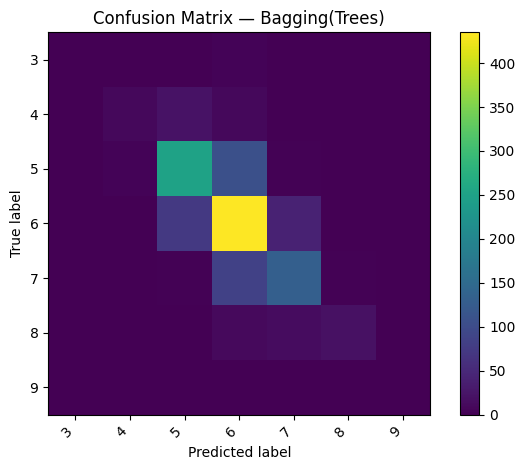

In [6]:
# Confusion matrix for the best Macro-F1 model
best_name = res_df.sort_values("MacroF1", ascending=False).iloc[0]["Model"]
best_model = models[best_name]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(range(len(np.unique(y_test))), np.unique(y_test), rotation=45, ha="right")
plt.yticks(range(len(np.unique(y_test))), np.unique(y_test))
plt.colorbar()
plt.tight_layout()
plt.show()

### بحث (به چه نکاتی توجه کنیم)

۱) **درخت تصمیم پر‌واریانس است**: یک درخت منفرد می‌تواند به جزئیات تصادفی split حساس باشد و نتیجهٔ تست ناپایدار شود.

۲) **Bagging و Random Forest معمولاً درخت‌ها را پایدار می‌کنند**:
- Bagging با میانگین‌گیری از درخت‌های bootstrap‌شده واریانس را کاهش می‌دهد.
- Random Forest با تصادفی‌سازی ویژگی‌ها تنوع را بیشتر می‌کند و غالباً تعمیم بهتر می‌دهد.

۳) **Soft voting می‌تواند از هر عضو منفرد بهتر باشد** اگر:
- اعضا به‌اندازهٔ کافی خوب باشند،
- خطاها کاملاً هم‌بسته نباشند،
- برآورد احتمال‌ها خیلی بد نباشد.

یک heuristic مهندسی:
> قبل از روش‌های پیچیده‌تر، یک baseline متنوعِ **Soft Voting** را امتحان کنید.

---



## ۸) آزمایش B (رگرسیون): میانگین‌گیری از پیش‌بین‌ها و کاهش واریانس

در این بخش:
- ستون هدف رگرسیون را تشخیص می‌دهیم،
- مدل‌های منفرد را با میانگین‌گیری انسمبلی مقایسه می‌کنیم،
- و نمودار **Predicted vs True** را رسم می‌کنیم.

مدل‌ها:
- DecisionTreeRegressor (واریانس زیاد)
- Ridge regression (واریانس کم)
- RandomForestRegressor (bagging + تصادفی‌سازی ویژگی)
- GradientBoostingRegressor (مدل جمعی از نوع boosting)
- VotingRegressor (میانگین‌گیری ساده از رگرسورها)

سنجه‌ها:
- MAE
- RMSE
- $R^2$



In [7]:
# Prepare regression X, y
y_reg = reg_df[ycol_reg]
X_reg = reg_df.drop(columns=[ycol_reg])

# Some datasets have date/time columns; keep them as strings => treated as categorical by preprocessor
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=11
)

pre_reg = make_preprocessor(X_train_r, scale_numeric=True)

ridge = Ridge(alpha=1.0, random_state=11)
tree_r = DecisionTreeRegressor(random_state=11)
rf_r = RandomForestRegressor(n_estimators=500, random_state=11, n_jobs=-1)
gbr = GradientBoostingRegressor(random_state=11)

pipe_ridge = Pipeline([("pre", pre_reg), ("model", ridge)])
pipe_tree  = Pipeline([("pre", pre_reg), ("model", tree_r)])
pipe_rf    = Pipeline([("pre", pre_reg), ("model", rf_r)])
pipe_gbr   = Pipeline([("pre", pre_reg), ("model", gbr)])

voter = VotingRegressor(
    estimators=[
        ("ridge", pipe_ridge),
        ("tree", pipe_tree),
        ("rf", pipe_rf),
        ("gbr", pipe_gbr),
    ]
)

models_reg = {
    "Ridge": pipe_ridge,
    "DecisionTree": pipe_tree,
    "RandomForest": pipe_rf,
    "GradientBoosting": pipe_gbr,
    "VotingRegressor(4 models)": voter,
}

def evaluate_regressor(model, X_test, y_test):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    # RMSE (compat across scikit-learn versions; squared= is deprecated in newer versions)
    try:
        from sklearn.metrics import root_mean_squared_error
        rmse = root_mean_squared_error(y_test, pred)
    except Exception:
        rmse = mean_squared_error(y_test, pred, squared=False)
    r2 = r2_score(y_test, pred)
    return mae, rmse, r2

reg_results = []
for name, m in models_reg.items():
    m.fit(X_train_r, y_train_r)
    mae, rmse, r2 = evaluate_regressor(m, X_test_r, y_test_r)
    reg_results.append((name, mae, rmse, r2))

reg_res_df = pd.DataFrame(reg_results, columns=["Model", "MAE", "RMSE", "R2"])
reg_res_df.sort_values("RMSE")

,Model,MAE,RMSE,R2
2,RandomForest,3.143046,27.929269,0.999950
1,DecisionTree,2.987838,33.744433,0.999928
3,GradientBoosting,137.762937,215.556852,0.997047
4,VotingRegressor(4 models),191.414154,294.812096,0.994476
0,Ridge,736.331599,1109.632014,0.921747


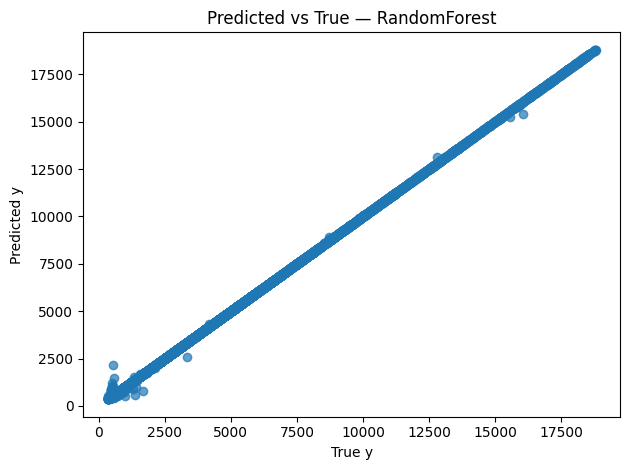

In [8]:
best_name_r = reg_res_df.sort_values("RMSE").iloc[0]["Model"]
best_model_r = models_reg[best_name_r]
pred = best_model_r.predict(X_test_r)

plt.figure()
plt.scatter(y_test_r, pred, alpha=0.7)
plt.title(f"Predicted vs True — {best_name_r}")
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.tight_layout()
plt.show()

### یک میکرو-اثبات کاربردی: میانگین‌گیری خطای مربعی را کم می‌کند اگر خطاها کاملاً هم‌بسته نباشند

فرض کنید پیش‌بین‌های پایه خروجی $\hat{y}_m = y + \epsilon_m$ بدهند و $\mathbb{E}[\epsilon_m]=0$.
انسمبل میانگین: $\bar{y} = \frac{1}{M}\sum_m \hat{y}_m$.

آنگاه $\bar{y} - y = \bar{\epsilon}$ و داریم:

$$
\mathbb{E}\big[(\bar{y}-y)^2\big] = \mathrm{Var}(\bar{\epsilon}).
$$

اگر $\mathrm{Var}(\epsilon_m)=\sigma^2$ و $\mathrm{Corr}(\epsilon_i,\epsilon_j)=\rho$ برای $i\ne j$ باشد:

$$
\mathrm{Var}(\bar{\epsilon})
=
\frac{\sigma^2}{M}\big(1+(M-1)\rho\big).
$$

پس **هر کاهش در هم‌بستگی** $\rho$ مستقیماً انسمبل را بهتر می‌کند — حتی اگر مدل‌های منفرد تغییر نکنند.

این دلیل ارزش‌مند بودن تصادفی‌سازی (bootstrap، ویژگی‌های تصادفی، splitهای تصادفی) است.

---



## ۹) آزمایش C (مصنوعی): مشاهدهٔ کاهش واریانس با افزایش تعداد estimatorها

در داده‌های واقعی، «واریانس» مستقیماً قابل مشاهده نیست. می‌توانیم با تکرار آموزش با seedهای مختلف و اندازه‌گیری تغییرپذیری پیش‌بینی‌ها، یک تقریب تجربی از واریانس داشته باشیم.

در این آزمایش:
- یک دیتاست رگرسیون غیرخطیِ نویزی می‌سازیم،
- انسمبل‌هایی با تعداد مختلف درخت آموزش می‌دهیم،
- و واریانس تجربی پیش‌بینی‌ها را در تکرارهای متعدد برآورد می‌کنیم.

اگر نظریه درست باشد، با افزایش $M$ واریانس پیش‌بینی کاهش می‌یابد.



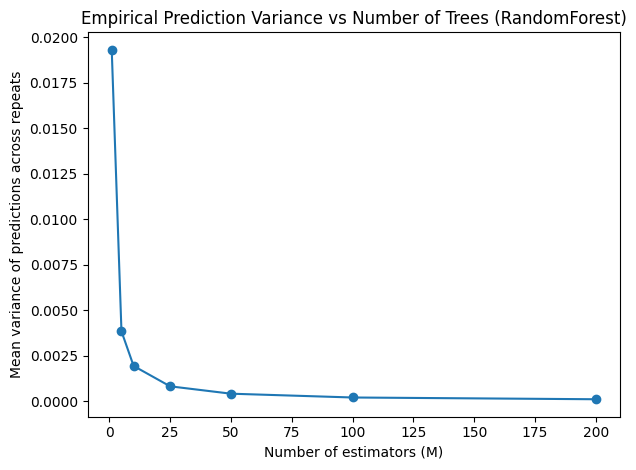

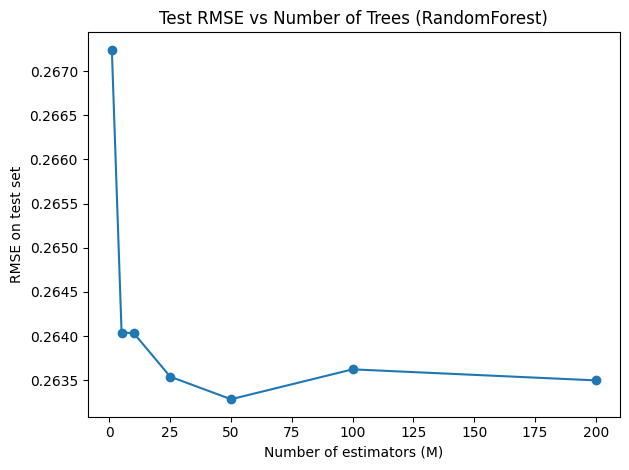

In [9]:
from sklearn.datasets import make_regression

def synthetic_data(seed=7, n=600):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-3, 3, size=(n, 1))
    y = np.sin(X[:, 0]) + 0.2 * rng.normal(size=n)
    return X, y

X_syn, y_syn = synthetic_data(seed=7, n=800)
Xtr, Xte, ytr, yte = train_test_split(X_syn, y_syn, test_size=0.25, random_state=7)

def fit_predict_rf(n_estimators, seed):
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=seed,
        n_jobs=-1,
        max_depth=None
    )
    rf.fit(Xtr, ytr)
    return rf.predict(Xte)

grid_M = [1, 5, 10, 25, 50, 100, 200]
repeats = 25

pred_var = []
pred_rmse = []

for M in grid_M:
    preds = np.vstack([fit_predict_rf(M, seed=1000+i) for i in range(repeats)])  # (repeats, n_test)
    var = preds.var(axis=0).mean()
    rmse = np.sqrt(((preds.mean(axis=0) - yte) ** 2).mean())
    pred_var.append(var)
    pred_rmse.append(rmse)

plt.figure()
plt.plot(grid_M, pred_var, marker="o")
plt.title("Empirical Prediction Variance vs Number of Trees (RandomForest)")
plt.xlabel("Number of estimators (M)")
plt.ylabel("Mean variance of predictions across repeats")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(grid_M, pred_rmse, marker="o")
plt.title("Test RMSE vs Number of Trees (RandomForest)")
plt.xlabel("Number of estimators (M)")
plt.ylabel("RMSE on test set")
plt.tight_layout()
plt.show()

## ۱۰) راهنمای عملی: چه زمانی انسمبل کمک می‌کند (و چه زمانی نه)

### ۱۰.۱ مواردی که انسمبل معمولاً کمک می‌کند
- مدل پایه **ناپایدار** و پر‌واریانس باشد (درخت تصمیم مثال کلاسیک است).
- بتوانید **تنوع معنی‌دار** ایجاد کنید.
- پروتکل ارزیابی درست باشد (بدون leakage، split مناسب، سنجه‌های درست).

### ۱۰.۲ مواردی که ممکن است کمک کم باشد
- مدل‌های پایه بسیار پایدار و شبیه هم باشند (مثلاً دو مدل خطی تقریباً یکسان).
- داده خیلی کوچک باشد و resampling مجموعه‌های آموزشی تقریباً یکسان بدهد.
- leakage غالب باشد: هر مدلی خوب به نظر می‌رسد.
- هدف تفسیرپذیری باشد و انسمبل بیش از حد پیچیده شود (tradeoff).

### ۱۰.۳ هزینه‌ها و دام‌ها
- محاسبات: $M$ مدل یعنی تقریباً $M$ برابر زمان آموزش (به‌علاوهٔ سربار).
- تنظیم: انسمبل‌ها هایپرپارامتر دارند (n_estimators, depth, learning_rate, ...).
- کالیبراسیون: برخی انسمبل‌ها بدکالیبره می‌شوند. اگر تصمیم‌گیری به احتمال‌ها وابسته است، کالیبراسیون را ارزیابی کنید.

---



## ۱۱) تمرین‌ها (پیشنهادی)

### مفهومی / نظری
۱) همانیِ واریانس را استخراج کنید:
   $$
   \mathrm{Var}\!\left(\frac{1}{M}\sum_{m=1}^M Z_m\right)
   =
   \frac{1}{M^2}\sum_m \mathrm{Var}(Z_m)
   +\frac{2}{M^2}\sum_{i<j}\mathrm{Cov}(Z_i, Z_j).
   $$
   سپس با فرض واریانس برابر و هم‌بستگی برابر، فرمول $\frac{\sigma^2}{M}(1+(M-1)\rho)$ را به دست آورید.

۲) برای رأی اکثریت با خطاهای مستقل، احتمال tail دوجمله‌ای را برای
   $p \in \{0.45, 0.4, 0.3\}$ و $M$ تا ۱۰۱ به‌صورت عددی رسم کنید. چه مشاهده می‌کنید؟

۳) توضیح دهید چرا هم‌بستگی خطاها «دشمن پنهان» انسمبل‌هاست.

### کدنویسی
۴) آزمایش طبقه‌بندی را طوری تغییر دهید که رأی‌گیری **hard voting** باشد و نتایج را مقایسه کنید.

۵) در آزمایش رگرسیون، DecisionTreeRegressor را از VotingRegressor حذف کنید. آیا RMSE تغییر کرد؟ چرا ممکن است چنین شود؟

۶) اگر در نسخهٔ scikit-learn شما موجود است، مدل‌های **ExtraTrees** را اضافه و با RandomForest مقایسه کنید.

---



## ۱۳) Bagging با جزئیات بیشتر: توزیع bootstrap و اینکه چرا یادگیرنده‌های «ناپایدار» سود می‌برند

### ۱۳.۱ دیدگاه توزیع bootstrap

یک الگوریتم یادگیری را به‌صورت یک نگاشت $\mathcal{T}$ در نظر بگیرید که از یک دیتاست، پیش‌بین می‌سازد:

$$
\hat{f} = \mathcal{T}(D), \quad D=\{(x_i,y_i)\}_{i=1}^n.
$$

اگر دیتاست $D$ تصادفی باشد، $\hat{f}$ هم تصادفی است. Bagging عملاً *امیدریاضی* پیش‌بین را روی یک توزیع بازنمونه‌گیری برآورد می‌کند.

نمونهٔ bootstrap $D^{(b)}$ را با نمونه‌برداری $n$ نقطه **با جایگزینی** از $D$ می‌سازیم.
آنگاه پیش‌بین bagged:

$$
\hat{f}_{\text{bag}}(x) = \frac{1}{B}\sum_{b=1}^B \mathcal{T}(D^{(b)})(x).
$$

این یک تقریب مونت‌کارلو از عبارت زیر است:

$$
\mathbb{E}_{D^\star \sim \text{Bootstrap}(D)}\big[\mathcal{T}(D^\star)(x)\big].
$$

### ۱۳.۲ چرا bagging به یادگیرنده‌های ناپایدار کمک می‌کند (شهود + نکتهٔ فنی)

یک یادگیرنده **ناپایدار** است اگر تغییرات کوچک در دادهٔ آموزش باعث تغییرات بزرگ در پیش‌بینی شود:
درخت تصمیم (بدون pruning)، kNN با $k$ کوچک، و چندجمله‌ای‌های درجه‌بالا نمونه‌های رایج‌اند.

Bagging معمولاً بیشترین کمک را زمانی می‌کند که:
- واریانس یادگیرنده زیاد باشد،
- بایاس خیلی بزرگ نباشد،
- و bootstrap نمونه‌های آموزشی کافی متفاوت ایجاد کند (تنوع).

نکتهٔ فنی: برای هزینهٔ مربعی، میانگین‌گیری واریانس را کاهش می‌دهد و حتی اگر بایاس ثابت بماند، می‌تواند ریسک کلی را کم کند.

### ۱۳.۳ چند حقیقت bootstrap که در عمل مهم‌اند

اگر از $n$ نقطه، $n$ بار با جایگزینی نمونه‌برداری کنید:
- امید ریاضیِ سهمِ نقاطِ یکتا در هر bootstrap حدود $1 - e^{-1} \approx 0.632$ است،
- بنابراین حدود $36.8\%$ از نقاط اصلی برای هر مدل **out-of-bag** هستند.

این پایهٔ ارزیابی OOB است (در درس‌های بعدی)، و همچنین توضیح می‌دهد چرا نمونه‌های bootstrap به‌اندازهٔ کافی متفاوت‌اند تا تنوع ایجاد کنند.

---



In [10]:
# Optional: quick bagging sensitivity study (how much does max_samples matter?)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

def cv_macro_f1(model):
    scores = cross_val_score(model, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    return scores.mean(), scores.std()

bag_grid = []
for ms in [0.5, 0.7, 0.9, 1.0]:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=7),
        n_estimators=250,
        max_samples=ms,
        bootstrap=True,
        random_state=7,
        n_jobs=-1
    )
    pipe = Pipeline([("pre", make_preprocessor(X, scale_numeric=True)), ("model", bag)])
    m, s = cv_macro_f1(pipe)
    bag_grid.append((ms, m, s))

pd.DataFrame(bag_grid, columns=["max_samples", "CV_MacroF1_mean", "CV_MacroF1_std"]).sort_values("CV_MacroF1_mean", ascending=False)

,max_samples,CV_MacroF1_mean,CV_MacroF1_std
3,1.0,0.423169,0.013178
2,0.9,0.421316,0.008137
1,0.7,0.413248,0.015760
0,0.5,0.404439,0.014936


## ۱۴) سنجش تنوع به‌صورت تجربی (عدم‌توافق و هم‌بستگی خطا)

نظریه می‌گوید هم‌بستگی مهم است. در این بخش، روی مجموعهٔ تست، سنجه‌های تنوع را برای مدل‌های طبقه‌بندی محاسبه می‌کنیم.

محاسبه می‌کنیم:
- **ماتریس عدم‌توافق**: $d_{ij} = \frac{1}{n}\sum_k \mathbf{1}[\hat{y}_i^{(k)} \ne \hat{y}_j^{(k)}]$.
- **ماتریس هم‌بستگی خطا**: هم‌بستگی نشانگرهای خطا $e_i^{(k)} = \mathbf{1}[\hat{y}_i^{(k)} \ne y^{(k)}]$.

تعبیر:
- عدم‌توافق بیشتر می‌تواند خوب باشد **اگر** مدل‌های منفرد خیلی ضعیف نباشند.
- هم‌بستگی خطای بالا معمولاً یعنی سود انسمبل کم خواهد بود.

---

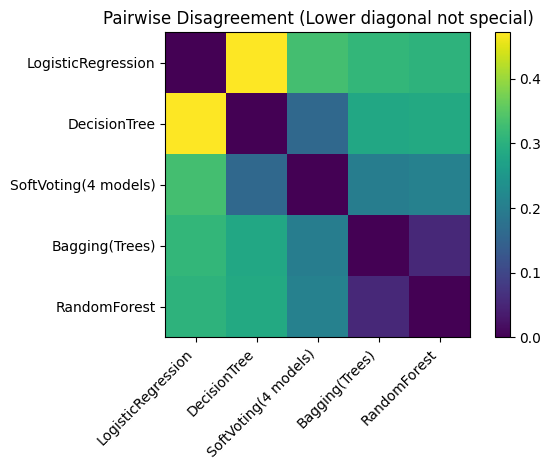

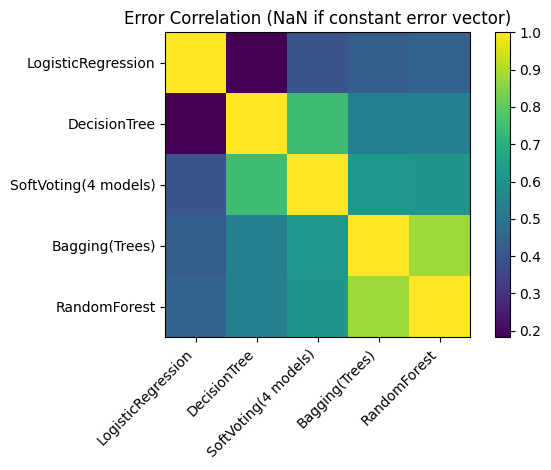

In [11]:
# Diversity diagnostics on the classification test set
trained_names = []
preds = []
errs = []

for name, model in models.items():
    model.fit(X_train, y_train)
    yhat = model.predict(X_test)
    trained_names.append(name)
    preds.append(yhat)
    errs.append((yhat != y_test).astype(int).to_numpy())

preds = np.vstack(preds)  # (n_models, n_test)
errs  = np.vstack(errs)   # (n_models, n_test)

# Disagreement matrix
n_models = preds.shape[0]
disagree = np.zeros((n_models, n_models))
for i in range(n_models):
    for j in range(n_models):
        disagree[i, j] = np.mean(preds[i] != preds[j])

# Error correlation matrix (handle constant vectors safely)
corr = np.zeros((n_models, n_models))
for i in range(n_models):
    for j in range(n_models):
        a, b = errs[i], errs[j]
        if a.std() == 0 or b.std() == 0:
            corr[i, j] = np.nan
        else:
            corr[i, j] = np.corrcoef(a, b)[0, 1]

plt.figure()
plt.imshow(disagree, interpolation="nearest")
plt.title("Pairwise Disagreement (Lower diagonal not special)")
plt.xticks(range(n_models), trained_names, rotation=45, ha="right")
plt.yticks(range(n_models), trained_names)
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure()
plt.imshow(corr, interpolation="nearest")
plt.title("Error Correlation (NaN if constant error vector)")
plt.xticks(range(n_models), trained_names, rotation=45, ha="right")
plt.yticks(range(n_models), trained_names)
plt.colorbar()
plt.tight_layout()
plt.show()

## ۱۵) Soft voting در برابر hard voting (و اینکه هرکدام کِی مناسب‌اند)

### ۱۵.۱ Hard voting

Hard voting برچسب‌ها را تجمیع می‌کند:

$$
\hat{y}_{\text{hard}}(x) = \arg\max_{c} \sum_{m=1}^{M}\mathbf{1}[\hat{y}_m(x)=c].
$$

Hard voting زمانی مقاوم‌تر است که:
- برآورد احتمال‌ها ضعیف یا در دسترس نباشد،
- مدل‌های پایه کالیبراسیون مشابهی داشته باشند (یا اصلاً به احتمال‌ها نیاز نداشته باشید).

### ۱۵.۲ Soft voting

Soft voting احتمال‌ها را تجمیع می‌کند:

$$
\hat{p}_{\text{soft}}(y=c\mid x)=\frac{1}{M}\sum_{m=1}^M \hat{p}_m(y=c\mid x), \qquad
\hat{y}_{\text{soft}}(x)=\arg\max_c \hat{p}_{\text{soft}}(y=c\mid x).
$$

Soft voting معمولاً قوی‌تر است وقتی:
- مدل‌های پایه احتمال تولید کنند،
- و آن احتمال‌ها تا حدی کالیبره باشند (یا حداقل بسیار بد نباشند).

در ادامه هر دو را پیاده‌سازی و مقایسه می‌کنیم.

---

In [12]:
# Hard vs Soft voting comparison (robust: keep preprocessing outside VotingClassifier)

hard_voting = Pipeline([
    ("pre", pre),
    ("model", VotingClassifier(
        estimators=[("lr", lr), ("tree", tree), ("knn", knn), ("svc", svc)],
        voting="hard"
    ))
])

soft_voting = Pipeline([
    ("pre", pre),
    ("model", VotingClassifier(
        estimators=[("lr", lr), ("tree", tree), ("knn", knn), ("svc", svc)],
        voting="soft"
    ))
])

hard_voting.fit(X_train, y_train)
soft_voting.fit(X_train, y_train)

hard_acc = accuracy_score(y_test, hard_voting.predict(X_test))
soft_acc = accuracy_score(y_test, soft_voting.predict(X_test))

hard_f1 = f1_score(y_test, hard_voting.predict(X_test), average="macro")
soft_f1 = f1_score(y_test, soft_voting.predict(X_test), average="macro")

pd.DataFrame(
    [
        ("HardVoting", hard_acc, hard_f1),
        ("SoftVoting", soft_acc, soft_f1),
    ],
    columns=["Ensemble", "Accuracy", "MacroF1"]
)

,Ensemble,Accuracy,MacroF1
0,HardVoting,0.595918,0.280041
1,SoftVoting,0.631020,0.339171


## ۱۶) Stacking: یادگیری قاعدهٔ تجمیع (به‌صورت leakage-safe)

Voting یک قاعدهٔ ثابت دارد. اما Stacking یک مدلِ تجمیع‌گر را *یاد می‌گیرد*.

### ۱۶.۱ چرا stacking می‌تواند از voting بهتر باشد؟

اگر مدل‌های مختلف در نواحی مختلف فضای ویژگی بهتر باشند، یک meta-model می‌تواند این الگو را یاد بگیرد:

- «وقتی مدل A با اطمینان بالا پیش‌بینی می‌کند، به آن اعتماد کن.»
- «وقتی مدل B و C اختلاف دارند، B را ترجیح بده.»
- «برای یک subgroup مشخص، وزن مدل دیگری را بیشتر کن.»

### ۱۶.۲ stacking بدون leakage: پیش‌بینی‌های out-of-fold

یک دام رایج این است که مدل‌های پایه را روی کل آموزش train کنید و meta-model را روی پیش‌بینی‌های in-sample آموزش دهید (leakage).
Stacking درست، برای meta-training از پیش‌بینی‌های out-of-fold استفاده می‌کند.

در scikit-learn، `StackingClassifier` وقتی `cv=...` بدهید این کار را انجام می‌دهد.

---

In [13]:
from sklearn.ensemble import StackingClassifier

# Stacking (robust: preprocessing outside the stacking estimator)
stack = Pipeline([
    ("pre", pre),
    ("model", StackingClassifier(
        estimators=[("lr", lr), ("tree", tree), ("svc", svc)],
        final_estimator=LogisticRegression(max_iter=2000),
        cv=5,
        passthrough=False,  # set True to include original features along with base preds
        n_jobs=-1
    ))
])

stack.fit(X_train, y_train)
stack_acc = accuracy_score(y_test, stack.predict(X_test))
stack_f1  = f1_score(y_test, stack.predict(X_test), average="macro")

# Reuse the same soft_voting/hard_voting variables if they exist; otherwise compute quickly
try:
    soft_acc_val = soft_acc
    soft_f1_val  = soft_f1
except NameError:
    _soft = Pipeline([("pre", pre), ("model", VotingClassifier(
        estimators=[("lr", lr), ("tree", tree), ("knn", knn), ("svc", svc)],
        voting="soft"
    ))])
    _soft.fit(X_train, y_train)
    soft_acc_val = accuracy_score(y_test, _soft.predict(X_test))
    soft_f1_val  = f1_score(y_test, _soft.predict(X_test), average="macro")

try:
    hard_acc_val = hard_acc
    hard_f1_val  = hard_f1
except NameError:
    _hard = Pipeline([("pre", pre), ("model", VotingClassifier(
        estimators=[("lr", lr), ("tree", tree), ("knn", knn), ("svc", svc)],
        voting="hard"
    ))])
    _hard.fit(X_train, y_train)
    hard_acc_val = accuracy_score(y_test, _hard.predict(X_test))
    hard_f1_val  = f1_score(y_test, _hard.predict(X_test), average="macro")

pd.DataFrame(
    [
        ("SoftVoting(4)", soft_acc_val, soft_f1_val),
        ("HardVoting(4)", hard_acc_val, hard_f1_val),
        ("Stacking(3->LR)", stack_acc, stack_f1),
    ],
    columns=["Method", "Accuracy", "MacroF1"]
).sort_values("MacroF1", ascending=False)

,Method,Accuracy,MacroF1
0,SoftVoting(4),0.631020,0.339171
2,Stacking(3->LR),0.608980,0.332966
1,HardVoting(4),0.595918,0.280041


## ۱۷) کالیبراسیون احتمال و قابلیت اعتماد (در تصمیم‌گیری مهم است)

Accuracy همه‌چیز نیست. در بسیاری از کاربردها به **احتمال‌های کالیبره** نیاز دارید:
- triage پزشکی،
- امتیازدهی ریسک،
- انتخاب آستانه بر اساس هزینه،
- رتبه‌بندی بر مبنای مطلوبیتِ مورد انتظار.

یک طبقه‌بند (کاملاً) کالیبره است اگر:

$$
\mathbb{P}(Y=1 \mid \hat{p}(X)=t) = t \quad \text{برای همهٔ } t \in [0,1].
$$

### ۱۷.۱ نمودار قابلیت اعتماد (calibration curve)

پیش‌بینی‌ها را بر اساس confidence bin می‌کنیم و مقایسه می‌کنیم:
- احتمال پیش‌بینی‌شده (محور x)،
- سهم تجربی مثبت‌ها (محور y).

اگر منحنی زیر قطر باشد، مدل **overconfident** است و اگر بالای قطر باشد **underconfident**.

در ادامه، یک reliability diagram برای یک مدل احتمالاتی رسم می‌کنیم (اگر predict_proba موجود باشد).

---

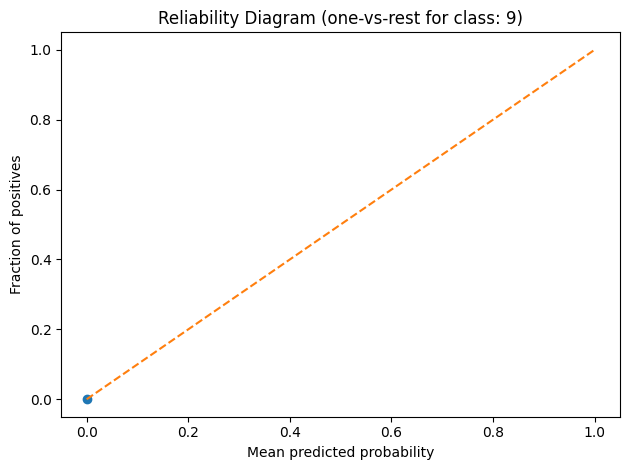

In [14]:
from sklearn.calibration import calibration_curve

# Choose a probabilistic model for calibration demo (use soft voting; hard voting has no predict_proba)
cal_model = Pipeline([
    ("pre", pre),
    ("model", VotingClassifier(
        estimators=[("lr", lr), ("tree", tree), ("knn", knn), ("svc", svc)],
        voting="soft"
    ))
])

cal_model.fit(X_train, y_train)

# Classes are stored on the VotingClassifier inside the Pipeline
inner = cal_model.named_steps["model"]
classes = inner.classes_
pos_class = classes[-1]  # pick one class as "positive" for one-vs-rest view

y_bin = (y_test == pos_class).astype(int)

proba = cal_model.predict_proba(X_test)
idx = list(classes).index(pos_class)
p_pos = proba[:, idx]

frac_pos, mean_pred = calibration_curve(y_bin, p_pos, n_bins=10, strategy="uniform")

plt.figure()
plt.plot(mean_pred, frac_pos, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"Reliability Diagram (one-vs-rest for class: {pos_class})")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.tight_layout()
plt.show()

## ۱۸) پیش‌نمایش boosting: مدل‌های جمعی و marginها (مفهومی)

هرچند این درس روی «انسمبل چیست» تمرکز دارد، بد نیست بدانیم چرا boosting می‌تواند بایاس را کاهش دهد.

AdaBoost را می‌توان به‌صورت یک مدل جمعی نوشت:

$$
F_M(x) = \sum_{m=1}^M \alpha_m h_m(x),
$$

و در طبقه‌بندی دودویی معمولاً:

$$
\hat{y}(x) = \mathrm{sign}(F_M(x)).
$$

یک دیدگاه کلاسیک: AdaBoost تقریباً کمینه‌سازی مرحله‌ایِ **exponential loss** را انجام می‌دهد:

$$
\sum_{i=1}^n \exp\big(-y_i F(x_i)\big), \quad y_i \in \{-1,+1\}.
$$

چون نمایی marginهای منفی $y_i F(x_i)$ را شدیداً تنبیه می‌کند، boosting تمایل دارد:
- marginها را روی نقاط سخت افزایش دهد،
- با تعداد زیادی weak learner مرزهای تصمیم پیچیده بسازد،
- و گاهی کمتر از انتظار overfit کند (در تکرارهای اولیه)، هرچند با estimatorهای زیاد ممکن است overfit شود.

در درس‌های بعدی با جزئیات بیشتری می‌بینید:
- learning rate (shrinkage)،
- محدودیت عمق درخت،
- early stopping با validation،
- و اینکه gradient boosting چگونه residual/negative gradient را fit می‌کند.

---



## ۱۲) منابع و مطالعهٔ بیشتر (شروع‌های باکیفیت)

- T. Hastie, R. Tibshirani, J. Friedman — *The Elements of Statistical Learning* (Ensembles, Bagging, Random Forests, Boosting)
- L. Breiman — “Bagging Predictors” و “Random Forests”
- Y. Freund, R. Schapire — کارهای بنیادی AdaBoost
- مستندات scikit-learn: ensemble methods, pipelines, ColumnTransformer, calibration, stacking

---

### پایان درس
در درس‌های بعدی فصل ۶ عمیق‌تر می‌شوید روی:
- bagging و OOB estimation،
- boosting و دیدگاه گرادیانی،
- stacking و blending،
- کالیبراسیون و انسمبل‌های دادهٔ نامتوازن.

